In [50]:
from vectorbtpro import *
import os

In [51]:
polygon_api_key = os.getenv('POLYGON_API_KEY')
vbt.PolygonData.set_custom_settings(client_config=dict(api_key=polygon_api_key))
data = vbt.PolygonData.pull(["X:BTCUSD"], start="2024-01-01", timeframe="1 day")
data = data.rename_symbols({'X:BTCUSD':'BTCUSD'})

In [52]:
@vbt.parameterized(merge_func="concat")  
def sma_crossover_perf(data, fast_window, slow_window):
    fast_sma = data.run("sma", fast_window, short_name="fast_sma")  # vbt.IF.list_indicators(), arguments can be of type vbt.param
    slow_sma = data.run("sma", slow_window, short_name="slow_sma")
    entries = fast_sma.real_crossed_above(slow_sma) 
    exits = fast_sma.real_crossed_below(slow_sma)
    pf = vbt.Portfolio.from_signals(data, entries, exits, direction="both") # enable shorts  
    return pf.sharpe_ratio

In [53]:
perf = sma_crossover_perf(  
    data["2025-01":"2025-07"],  
    # parameter combinations that meet pre-compiled condition
    vbt.Param(np.arange(5, 50), condition="x < slow_window"),  
    vbt.Param(np.arange(5, 50)),  
    # Parameterize decorator class args prefixed "_"
    _execute_kwargs=dict(
        clear_cache=50,  
        collect_garbage=50
    )
)

  5%|5         | 50/990 [00:10<03:24,  4.60it/s, fast_window=6, slow_window=13]

In [54]:
perf.sort_values(ascending=False)

fast_window  slow_window  fast_sma_timeperiod  slow_sma_timeperiod  symbol
39           40           39                   40                   BTCUSD    2.873848
5            40           5                    40                   BTCUSD    2.523921
             38           5                    38                   BTCUSD    2.523921
             39           5                    39                   BTCUSD    2.523921
37           41           37                   41                   BTCUSD    2.513683
                                                                                ...   
44           48           44                   48                   BTCUSD   -0.837749
16           17           16                   17                   BTCUSD   -0.953807
6            8            6                    8                    BTCUSD   -0.994493
27           28           27                   28                   BTCUSD   -1.277500
6            7            6                    7       

In [55]:
perf.idxmax()

(np.int64(39), np.int64(40), np.int64(39), np.int64(40), 'BTCUSD')

In [56]:
perf[perf.idxmax()]

np.float64(2.873847526493103)

In [57]:
best_fast_window, best_slow_window, _, _, _= perf.idxmax() 

In [58]:
perf = sma_crossover_perf(  
    data["2024-01":"2024-07"],  
    best_slow_window,  
    best_fast_window,  
    # Parameterize decorator class args prefixed "_"
    _execute_kwargs=dict(
        clear_cache=50,  
        collect_garbage=50
    )
)

In [59]:
perf.sort_values(ascending=False)

fast_sma_timeperiod  slow_sma_timeperiod  symbol
40                   39                   BTCUSD    0.743311
Name: sharpe_ratio, dtype: float64

SMA Crossover underperformance for 2024-01 to 2024-07 where the same strat had Sharpe > 2.0 for 2025-01 to 2025-07

In [60]:
data["2024-01":"2024-07"].run("from_holding").sharpe_ratio

symbol
BTCUSD    1.481963
Name: sharpe_ratio, dtype: float64

Still outperforming just HODL

In [61]:
splitter = vbt.Splitter.from_n_rolling(
    data["2024-01":"2025-09"].index, 
    n=10,
    split=0.5,
    set_labels=["IS", "OOS"]
)

In [62]:
splitter.splits

set,IS,OOS
split,,
0,"slice(0, 31, None)","slice(31, 63, None)"
1,"slice(63, 94, None)","slice(94, 126, None)"
2,"slice(126, 157, None)","slice(157, 189, None)"
3,"slice(189, 220, None)","slice(220, 252, None)"
4,"slice(252, 283, None)","slice(283, 315, None)"
5,"slice(315, 346, None)","slice(346, 378, None)"
6,"slice(378, 409, None)","slice(409, 441, None)"
7,"slice(441, 472, None)","slice(472, 504, None)"
8,"slice(504, 535, None)","slice(535, 567, None)"


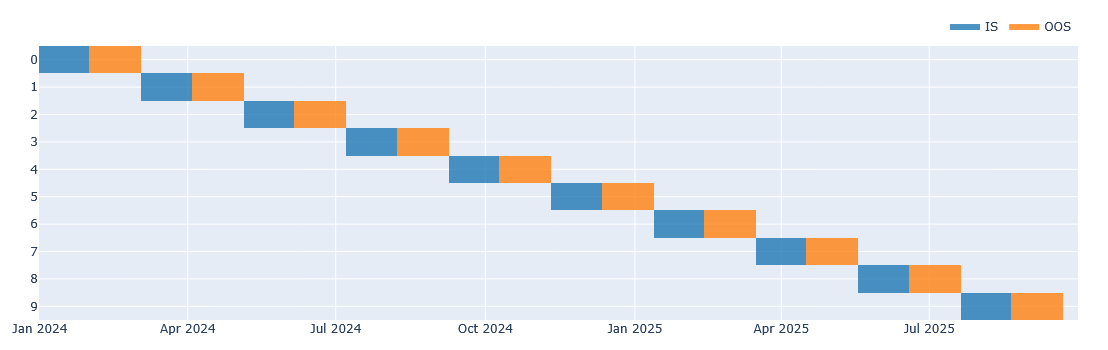

In [63]:
splitter.plot().show()

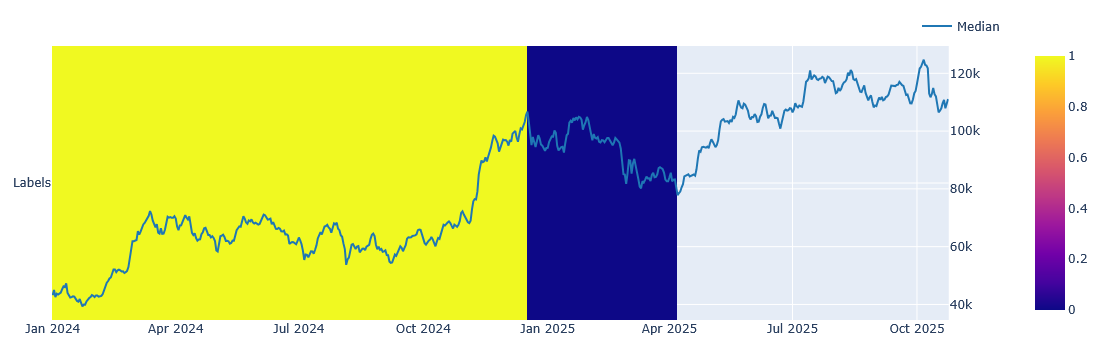

In [49]:
trendlb = data.run("trendlb", 1.0, 0.15)
trendlb.plot().show()